# Tema 5: Clustering Kabupaten/Kota Aceh Berdasarkan Proporsi Dasar vs Menengah

**Skenario 1 — Clustering** | Dataset: `data_bersih.csv`

**Pertanyaan:** Kabupaten mana yang porsi sumber dayanya lebih besar di pendidikan dasar (SD+SMP) dibanding menengah (SMA+SMK)?

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

print("Library berhasil diimport.")

Library berhasil diimport.


## 2. Load Dataset

In [2]:
df = pd.read_csv("data_bersih.csv")

print("Ukuran data :", df.shape)
print("Jumlah kabupaten :", df["kabupaten_kota"].nunique())
print("Rentang tahun :", df["tahun"].min(), "-", df["tahun"].max())
print("Missing Value :", df.isna().sum().sum())
print("Duplikat :", df.duplicated().sum())

display(df.head())

Ukuran data : (230, 41)
Jumlah kabupaten : 23
Rentang tahun : 2016 - 2025
Missing Value : 0
Duplikat : 0


,kabupaten_kota,tahun,hls__nilai,rls__nilai,amh__nilai,sd__Jumlah Sekolah SD (Negeri),sd__Jumlah Sekolah SD (Swasta),sd__Jumlah Sekolah SD (Negeri+Swasta),sd__Jumlah Guru SD (Negeri),sd__Jumlah Guru SD (Swasta),sd__Jumlah Guru SD (Negeri+Swasta),sd__Jumlah Murid SD (Negeri),sd__Jumlah Murid SD (Swasta),sd__Jumlah Murid SD (Negeri+Swasta),smp__Jumlah Sekolah SMP (Negeri),smp__Jumlah Sekolah SMP (Swasta),smp__Jumlah Sekolah SMP (Negeri+Swasta),smp__Jumlah Guru SMP (Negeri),smp__Jumlah Guru SMP (Swasta),smp__Jumlah Guru SMP (Negeri+Swasta),smp__Jumlah Murid SMP (Negeri),smp__Jumlah Murid SMP (Swasta),smp__Jumlah Murid SMP (Negeri+Swasta),sma__Jumlah Sekolah SMA (Negeri),sma__Jumlah Sekolah SMA (Swasta),sma__Jumlah Sekolah SMA (Negeri+Swasta),sma__Jumlah Guru SMA (Negeri),sma__Jumlah Guru SMA (Swasta),sma__Jumlah Guru SMA (Negeri+Swasta),sma__Jumlah Murid SMA (Negeri),sma__Jumlah Murid SMA (Swasta),sma__Jumlah Murid SMA (Negeri+Swasta),smk__Jumlah Sekolah SMK (Negeri),smk__Jumlah Sekolah SMK (Swasta),smk__Jumlah Sekolah SMK (Negeri+Swasta),smk__Jumlah Guru SMK (Negeri),smk__Jumlah Guru SMK (Swasta),smk__Jumlah Guru SMK (Negeri+Swasta),smk__Jumlah Murid SMK (Negeri),smk__Jumlah Murid SMK (Swasta),smk__Jumlah Murid SMK (Negeri+Swasta)
0,Kabupaten Aceh Barat,2016,14.56,8.70,97.84,148,4,153,2125,48,2315,15757,422,16233,39,10,49,658,93,751,5270,698,5968,17,4,21,434,58,492,4404,570,4974,10,1,11,297,16,313,2469,42,2511
1,Kabupaten Aceh Barat,2017,14.57,9.04,97.84,150,3,153,2050,41,2091,16169,414,16583,45,8,53,727,88,815,5427,631,6058,17,4,21,431,61,492,4365,675,5040,10,1,11,296,14,310,2578,26,2604
2,Kabupaten Aceh Barat,2018,14.58,9.08,97.84,150,3,153,2127,36,2163,15694,467,16161,45,9,54,757,106,863,5391,783,6174,17,4,21,421,65,486,4269,639,4908,10,1,11,300,15,316,2606,30,2635
3,Kabupaten Aceh Barat,2019,14.59,9.09,97.84,150,3,153,2276,39,2315,15718,515,16233,45,11,56,774,130,904,5649,1006,6655,17,4,21,423,67,490,4289,652,4941,10,1,11,305,16,321,2633,33,2666
4,Kabupaten Aceh Barat,2020,14.60,9.37,97.84,150,3,153,2367,38,2405,15377,542,15919,45,13,58,850,173,1023,5544,1176,6720,17,4,21,433,68,501,4077,642,4719,10,1,11,312,20,332,2619,66,2685


## 3. Agregasi ke Level Kabupaten/Kota

In [3]:
numeric_cols = df.columns.drop([
    "kabupaten_kota",
    "tahun"
])

agg = (
    df
    .groupby("kabupaten_kota")[numeric_cols]
    .mean()
    .reset_index()
)

print("Ukuran data setelah agregasi :", agg.shape)
display(agg.head())

Ukuran data setelah agregasi : (23, 40)


,kabupaten_kota,hls__nilai,rls__nilai,amh__nilai,sd__Jumlah Sekolah SD (Negeri),sd__Jumlah Sekolah SD (Swasta),sd__Jumlah Sekolah SD (Negeri+Swasta),sd__Jumlah Guru SD (Negeri),sd__Jumlah Guru SD (Swasta),sd__Jumlah Guru SD (Negeri+Swasta),sd__Jumlah Murid SD (Negeri),sd__Jumlah Murid SD (Swasta),sd__Jumlah Murid SD (Negeri+Swasta),smp__Jumlah Sekolah SMP (Negeri),smp__Jumlah Sekolah SMP (Swasta),smp__Jumlah Sekolah SMP (Negeri+Swasta),smp__Jumlah Guru SMP (Negeri),smp__Jumlah Guru SMP (Swasta),smp__Jumlah Guru SMP (Negeri+Swasta),smp__Jumlah Murid SMP (Negeri),smp__Jumlah Murid SMP (Swasta),smp__Jumlah Murid SMP (Negeri+Swasta),sma__Jumlah Sekolah SMA (Negeri),sma__Jumlah Sekolah SMA (Swasta),sma__Jumlah Sekolah SMA (Negeri+Swasta),sma__Jumlah Guru SMA (Negeri),sma__Jumlah Guru SMA (Swasta),sma__Jumlah Guru SMA (Negeri+Swasta),sma__Jumlah Murid SMA (Negeri),sma__Jumlah Murid SMA (Swasta),sma__Jumlah Murid SMA (Negeri+Swasta),smk__Jumlah Sekolah SMK (Negeri),smk__Jumlah Sekolah SMK (Swasta),smk__Jumlah Sekolah SMK (Negeri+Swasta),smk__Jumlah Guru SMK (Negeri),smk__Jumlah Guru SMK (Swasta),smk__Jumlah Guru SMK (Negeri+Swasta),smk__Jumlah Murid SMK (Negeri),smk__Jumlah Murid SMK (Swasta),smk__Jumlah Murid SMK (Negeri+Swasta)
0,Kabupaten Aceh Barat,14.664,9.466,98.080,149.9,4.4,154.4,2190.9,58.7,2263.8,15429.3,582.8,16017.5,44.7,13.0,57.7,824.1,143.5,967.6,5176.6,1158.6,6335.2,17.0,4.4,21.4,430.6,65.6,496.2,4177.3,634.3,4811.6,10.4,0.6,11.0,328.3,9.6,338.0,2680.8,25.2,2705.9
1,Kabupaten Aceh Barat Daya,13.616,8.487,96.099,107.0,3.0,110.0,1502.1,36.5,1533.4,11797.9,534.4,12335.5,24.0,6.2,30.2,562.3,74.6,636.9,4848.0,624.3,5472.3,13.0,2.0,15.0,419.2,31.4,450.6,4447.4,298.2,4745.6,5.0,0.0,5.0,154.6,0.0,154.6,1105.8,0.0,1105.8
2,Kabupaten Aceh Besar,14.688,10.240,98.490,201.4,11.0,212.5,2496.8,213.3,2710.3,27836.0,2984.1,30950.3,51.7,27.8,79.5,1071.0,308.9,1379.9,9573.2,4107.0,13680.2,28.2,17.0,45.2,822.2,200.5,1022.7,6390.1,2036.8,8426.9,7.9,2.9,10.8,379.3,32.1,411.4,2852.6,405.6,3258.2
3,Kabupaten Aceh Jaya,13.994,89.089,96.632,98.0,0.0,98.0,1051.8,0.0,1070.8,9124.1,0.0,9184.1,30.8,5.1,35.9,437.2,65.7,502.9,2840.6,642.7,3483.3,11.0,3.0,14.0,216.6,39.7,256.3,1954.1,437.9,2392.0,6.0,1.0,7.0,114.6,14.4,129.0,717.8,138.7,856.5
4,Kabupaten Aceh Selatan,14.372,8.671,96.996,201.5,3.2,204.9,2568.2,30.8,2586.0,19623.0,425.9,20074.0,52.1,7.7,59.8,940.9,82.4,1023.3,8098.2,685.4,8783.6,28.0,5.4,33.4,769.4,71.4,840.8,6486.9,465.3,6952.2,10.0,1.3,11.3,270.8,13.2,284.1,1449.4,80.2,1529.6


## 4. Feature Engineering

Fitur berupa proporsi murid, sekolah, dan guru jenjang dasar terhadap keseluruhan (dasar+menengah).

## 4.1. Integrasi Fitur Spasial untuk Spatial K-Means
**Penjelasan Metodologi Analisis Spasial:**
Untuk menjawab kebutuhan **Analisis Spasial (Spatial Analysis)**, algoritma K-Means kini menggunakan matriks fitur terintegrasi yang mencakup **fitur geografis/spasial** (`latitude` dan `longitude`) dari koordinat sentroid masing-masing Kabupaten/Kota di Provinsi Aceh, disamping indikator atribut pendidikan.

Dengan pendekatan **Spatial-Attribute K-Means** ini, pengelompokan yang dihasilkan oleh K-Means memperhitungkan dua dimensi secara simultan:
1. **Kedekatan Lokasi Geografis (Spatial Proximity)**: Memastikan wilayah yang secara geografis berdekatan/bertetangga dipertimbangkan dalam pembentukan klaster.
2. **Kemiripan Indikator Pendidikan (Attribute Similarity)**: Memastikan karakteristik atribut pendidikan (seperti HLS, RLS, AMH, dan rasio-rasio pendidikan) tetap dioptimalkan.


In [4]:
feat = pd.DataFrame()
feat["kabupaten_kota"] = agg["kabupaten_kota"]

# Fitur Koordinat Spasial (Latitude & Longitude)
koordinat_aceh = {
    'Kabupaten Aceh Barat': (4.45, 96.16),
    'Kabupaten Aceh Barat Daya': (3.83, 96.89),
    'Kabupaten Aceh Besar': (5.38, 95.52),
    'Kabupaten Aceh Jaya': (4.72, 95.64),
    'Kabupaten Aceh Selatan': (3.31, 97.18),
    'Kabupaten Aceh Singkil': (2.42, 97.93),
    'Kabupaten Aceh Tengah': (4.54, 96.91),
    'Kabupaten Aceh Tenggara': (3.37, 97.80),
    'Kabupaten Aceh Timur': (4.63, 97.63),
    'Kabupaten Aceh Utara': (4.97, 97.14),
    'Kabupaten Bener Meriah': (4.73, 96.86),
    'Kabupaten Bireuen': (5.14, 96.62),
    'Kabupaten Gayo Lues': (3.96, 97.33),
    'Kabupaten Nagan Raya': (4.16, 96.43),
    'Kabupaten Pidie': (5.16, 95.96),
    'Kabupaten Pidie Jaya': (5.23, 96.22),
    'Kabupaten Simeulue': (2.61, 96.08),
    'Kota Banda Aceh': (5.55, 95.32),
    'Kota Langsa': (4.47, 97.96),
    'Kota Lhokseumawe': (5.18, 97.14),
    'Kota Sabang': (5.88, 95.32),
    'Kota Subulussalam': (2.64, 97.93),
    'Kabupaten Aceh Tamiang': (4.25, 98.02)
}
feat['latitude'] = feat['kabupaten_kota'].map(lambda x: koordinat_aceh.get(x, (0,0))[0])
feat['longitude'] = feat['kabupaten_kota'].map(lambda x: koordinat_aceh.get(x, (0,0))[1])

# ======================
# Total Sekolah
# ======================

sekolah_dasar = (
    agg["sd__Jumlah Sekolah SD (Negeri+Swasta)"] +
    agg["smp__Jumlah Sekolah SMP (Negeri+Swasta)"]
)

sekolah_menengah = (
    agg["sma__Jumlah Sekolah SMA (Negeri+Swasta)"] +
    agg["smk__Jumlah Sekolah SMK (Negeri+Swasta)"]
)

# ======================
# Total Guru
# ======================

guru_dasar = (
    agg["sd__Jumlah Guru SD (Negeri+Swasta)"] +
    agg["smp__Jumlah Guru SMP (Negeri+Swasta)"]
)

guru_menengah = (
    agg["sma__Jumlah Guru SMA (Negeri+Swasta)"] +
    agg["smk__Jumlah Guru SMK (Negeri+Swasta)"]
)

# ======================
# Total Murid
# ======================

murid_dasar = (
    agg["sd__Jumlah Murid SD (Negeri+Swasta)"] +
    agg["smp__Jumlah Murid SMP (Negeri+Swasta)"]
)

murid_menengah = (
    agg["sma__Jumlah Murid SMA (Negeri+Swasta)"] +
    agg["smk__Jumlah Murid SMK (Negeri+Swasta)"]
)

# ======================
# Proporsi Dasar
# ======================

feat["prop_sekolah_dasar"] = (
    sekolah_dasar /
    (sekolah_dasar + sekolah_menengah)
)

feat["prop_guru_dasar"] = (
    guru_dasar /
    (guru_dasar + guru_menengah)
)

feat["prop_murid_dasar"] = (
    murid_dasar /
    (murid_dasar + murid_menengah)
)

feat.replace([np.inf, -np.inf], np.nan, inplace=True)
feat.fillna(0, inplace=True)

print("Ukuran fitur :", feat.shape)

display(feat.head())

Ukuran fitur : (23, 6)


,kabupaten_kota,latitude,longitude,prop_sekolah_dasar,prop_guru_dasar,prop_murid_dasar
0,Kabupaten Aceh Barat,4.45,96.16,0.867485,0.794815,0.748328
1,Kabupaten Aceh Barat Daya,3.83,96.89,0.875156,0.781949,0.752680
2,Kabupaten Aceh Besar,5.38,95.52,0.839080,0.740401,0.792507
3,Kabupaten Aceh Jaya,4.72,95.64,0.864429,0.803318,0.795896
4,Kabupaten Aceh Selatan,3.31,97.18,0.855527,0.762389,0.772846


## 5. Exploratory Data Analysis — Korelasi Antar Fitur

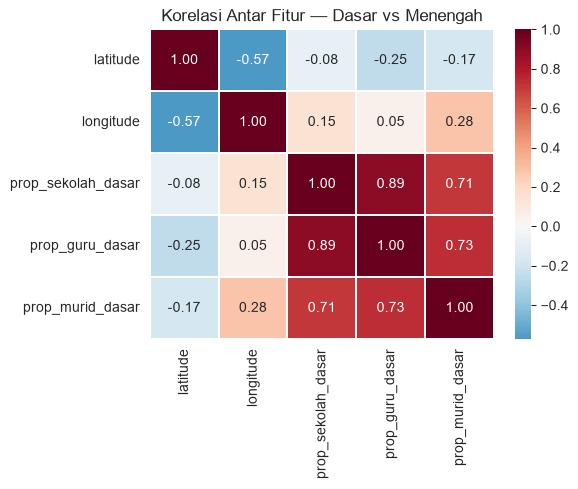

In [5]:

plt.figure(figsize=(6, 5))
corr = feat.drop(columns=['kabupaten_kota']).corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f', linewidths=0.3)
plt.title('Korelasi Antar Fitur — Dasar vs Menengah')
plt.tight_layout()
plt.show()


## 6. Standarisasi Fitur

In [6]:
X = feat.drop(columns=["kabupaten_kota"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Ukuran data setelah standarisasi :", X_scaled.shape)
print(
    "Rata-rata :",
    np.round(X_scaled.mean(axis=0), 3)
)
print(
    "Standar Deviasi :",
    np.round(X_scaled.std(axis=0), 3)
)

Ukuran data setelah standarisasi : (23, 5)
Rata-rata : [ 0.  0.  0.  0. -0.]
Standar Deviasi : [1. 1. 1. 1. 1.]


## 7. Menentukan Jumlah Cluster Optimal (Elbow Method & Silhouette Score)

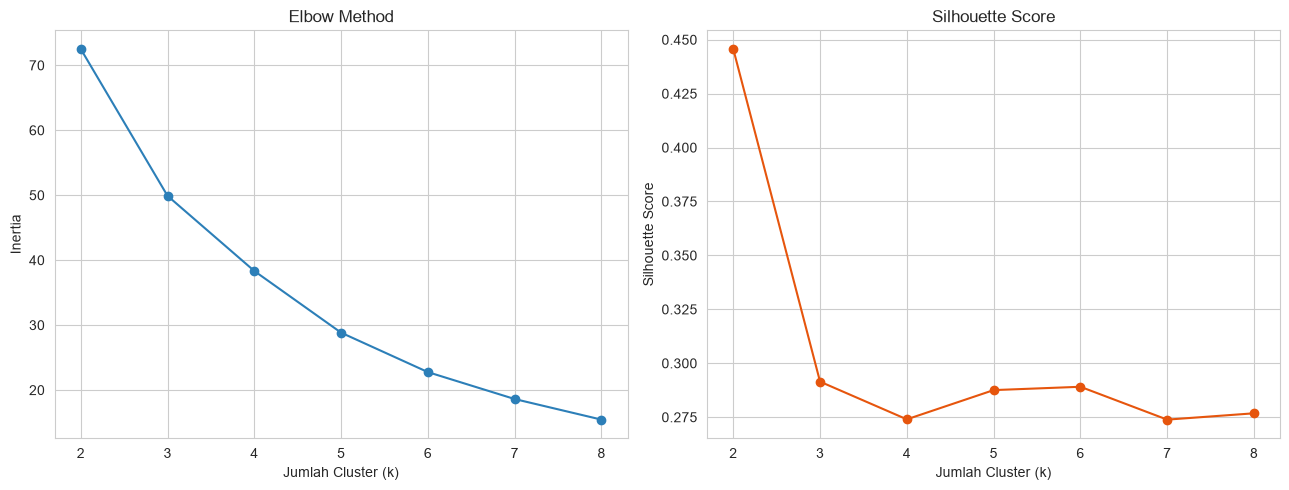

k=2: inertia=72.51, silhouette=0.4457
k=3: inertia=49.90, silhouette=0.2915
k=4: inertia=38.33, silhouette=0.2740
k=5: inertia=28.83, silhouette=0.2876
k=6: inertia=22.76, silhouette=0.2891
k=7: inertia=18.61, silhouette=0.2739
k=8: inertia=15.44, silhouette=0.2768


In [7]:
K_range = range(2, 9)

inertias = []
sil_scores = []

for k in K_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)

    sil_scores.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
axes[0].plot(K_range, inertias, marker="o", color="#2c7fb8")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Jumlah Cluster (k)")
axes[0].set_ylabel("Inertia")

# Silhouette
axes[1].plot(K_range, sil_scores, marker="o", color="#e6550d")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Jumlah Cluster (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

for k, i, s in zip(K_range, inertias, sil_scores):
    print(f"k={k}: inertia={i:.2f}, silhouette={s:.4f}")

## 8. Fit K-Means Final

In [8]:
best_k = K_range[np.argmax(sil_scores)]
best_score = max(sil_scores)

print("Jumlah Cluster Terbaik :", best_k)
print("Silhouette Score :", round(best_score, 4))

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

feat["cluster"] = kmeans.fit_predict(X_scaled)

print("\nJumlah anggota tiap cluster:")

print(
    feat["cluster"]
        .value_counts()
        .sort_index()
)

Jumlah Cluster Terbaik : 2
Silhouette Score : 0.4457

Jumlah anggota tiap cluster:
cluster
0     3
1    20
Name: count, dtype: int64


## 9. Daftar Kabupaten/Kota Tiap Cluster

In [9]:
for c in sorted(feat["cluster"].unique()):

    anggota = feat.loc[
        feat["cluster"] == c,
        "kabupaten_kota"
    ].tolist()

    print(f"\n{'=' * 50}")
    print(f"Cluster {c} ({len(anggota)} kabupaten/kota):")
    print(", ".join(anggota))


Cluster 0 (3 kabupaten/kota):
Kota Banda Aceh, Kota Langsa, Kota Lhokseumawe

Cluster 1 (20 kabupaten/kota):
Kabupaten Aceh Barat, Kabupaten Aceh Barat Daya, Kabupaten Aceh Besar, Kabupaten Aceh Jaya, Kabupaten Aceh Selatan, Kabupaten Aceh Singkil, Kabupaten Aceh Tamiang, Kabupaten Aceh Tengah, Kabupaten Aceh Tenggara, Kabupaten Aceh Timur, Kabupaten Aceh Utara, Kabupaten Bener Meriah, Kabupaten Bireuen, Kabupaten Gayo Lues, Kabupaten Nagan Raya, Kabupaten Pidie, Kabupaten Pidie Jaya, Kabupaten Simeulue, Kota Sabang, Kota Subulussalam


## 10. Visualisasi Cluster dengan PCA (2D)

Variance explained: 83.0 %


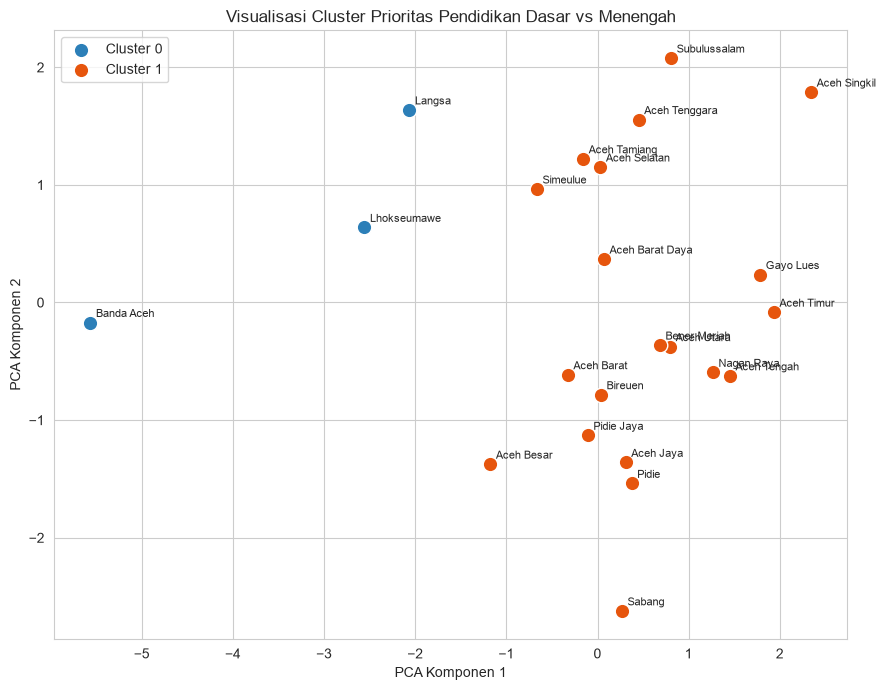

In [10]:

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Variance explained:", round(pca.explained_variance_ratio_.sum()*100, 1), "%")

plt.figure(figsize=(9, 7))
palette = ['#2c7fb8', '#e6550d', '#31a354', '#756bb1', '#de2d26'][:3]
for c in sorted(feat['cluster'].unique()):
    mask = feat['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=110, color=palette[c], label=f'Cluster {c}', edgecolor='white')
for i, row in feat.iterrows():
    plt.annotate(row['kabupaten_kota'].replace('Kabupaten ', '').replace('Kota ', ''),
                 (X_pca[i, 0], X_pca[i, 1]), fontsize=8, xytext=(4, 4), textcoords='offset points')
plt.xlabel('PCA Komponen 1'); plt.ylabel('PCA Komponen 2')
plt.title('Visualisasi Cluster Prioritas Pendidikan Dasar vs Menengah')
plt.legend()
plt.tight_layout()
plt.show()


## 11. Profil Rata-Rata Tiap Cluster

In [11]:
profile = (
    feat
    .drop(columns="kabupaten_kota")
    .groupby("cluster")
    .mean(numeric_only=True)
    .round(3)
)

display(profile)

,latitude,longitude,prop_sekolah_dasar,prop_guru_dasar,prop_murid_dasar
cluster,,,,,
0,5.067,96.807,0.797,0.674,0.727
1,4.269,96.778,0.870,0.786,0.791


## 12. Grafik Profil Cluster

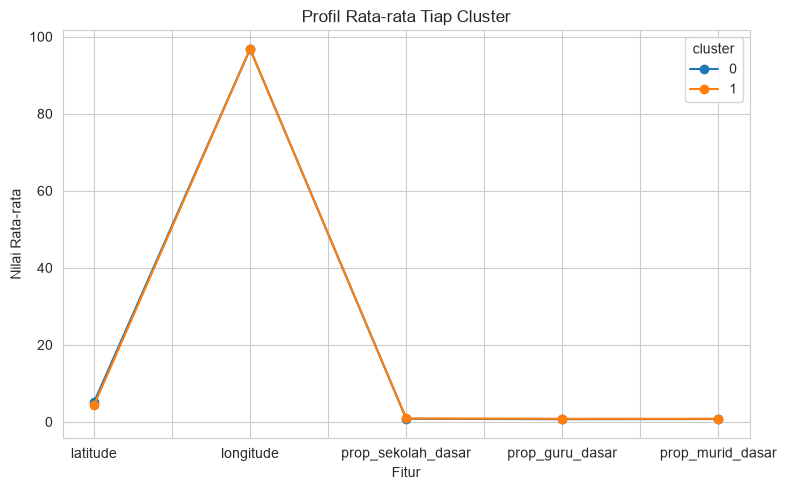

In [12]:
profile.T.plot(
    figsize=(8,5),
    marker="o"
)

plt.title("Profil Rata-rata Tiap Cluster")
plt.xlabel("Fitur")
plt.ylabel("Nilai Rata-rata")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
hasil_cluster = feat.copy()
hasil_cluster.to_csv("hasil_cluster_tema5.csv", index=False)
print("Hasil clustering berhasil disimpan.")

Hasil clustering berhasil disimpan.


## 13. Kesimpulan Analisis

Berdasarkan hasil K-Means (k = 2), kabupaten/kota di Aceh terbagi menjadi dua kelompok utama:

- **Cluster 0 (3 wilayah: Kota Banda Aceh, Kota Langsa, dan Kota Lhokseumawe)** memiliki proporsi pendidikan dasar yang relatif lebih rendah dibandingkan Cluster 1, terutama pada proporsi guru dasar (0,674). Kondisi ini menunjukkan bahwa distribusi sekolah, guru, dan murid di ketiga kota tersebut memiliki porsi pendidikan menengah (SMA/SMK) yang relatif lebih tinggi dibanding kabupaten lain.
- **Cluster 1 (20 kabupaten/kota)** mewakili mayoritas wilayah di Provinsi Aceh. Cluster ini memiliki proporsi sumber daya pendidikan dasar yang lebih tinggi, dengan rata-rata proporsi sekolah dasar sebesar 0,870, proporsi guru dasar 0,786, dan proporsi murid dasar 0,791. Hal ini menunjukkan bahwa sebagian besar sumber daya pendidikan di wilayah-wilayah tersebut masih lebih terfokus pada jenjang pendidikan dasar (SD dan SMP) dibandingkan jenjang pendidikan menengah.

**Interpretasi utama:**

Hasil clustering menunjukkan adanya perbedaan orientasi penyediaan layanan pendidikan antarwilayah di Provinsi Aceh. Mayoritas kabupaten masih didominasi oleh alokasi sumber daya pada pendidikan dasar, sedangkan beberapa kota memiliki distribusi yang lebih seimbang antara pendidikan dasar dan pendidikan menengah. Temuan ini dapat menjadi masukan dalam perencanaan pemerataan pembangunan pendidikan sesuai karakteristik masing-masing wilayah.